In [1]:
import os
import numpy as np

import torch as pt

import pickle

%matplotlib widget
from matplotlib import pyplot as plt
import matplotlib.cm as cm

## Notebook roadmap
This notebook reproduces **Figure 3** from the main text for the **1D transverse-field Ising model (TFIM)**.

In the paper, this figure demonstrates that distance learning on snapshot data:
- recovers the ferromagnetic/paramagnetic structure in TFIM,
- yields stable HDBSCAN clustering across system sizes,
- captures susceptibility behavior near the critical point and supports finite-size scaling analysis.

The main f-divergence matrices used here were generated by
`run_figure_3_main_distance_matrices.py` in `../data/figures/figure_3/main_distance_matrices/`.
If you are interested in the training setup, we invite you to inspect that script for hyperparameter details.

It goes through the following steps:
1. Configure the global plotting style used in the final figure.
2. Load pre-saved outputs of distance-learning experiments (pairwise divergence matrices and coordinates).
3. Load auxiliary FSSA and overlap-based reference data used for susceptibility/scaling panels.
4. Aggregate seeded results (arithmetic mean across seeds) and estimate uncertainty (standard error).
5. Run HDBSCAN on the precomputed distance matrices to obtain cluster labels and confidence values.
6. Build the full multi-panel figure (distance matrices, clustering confidence, susceptibility, and scaling collapse).
7. Export the final figure as `figure_3.pdf` and `figure_3.svg`.

Required local files (relative to `paper_figures/`):
- `../data/figures/figure_3/main_distance_matrices/seeded_f_matrices_dict.pickle`
- `../data/figures/figure_3/main_distance_matrices/coords_dict.pickle`
- `../data/figures/figure_3/system_size2small_window_large_systems_overlaps.pickle`
- FSSA `.npy` files in `../data/figures/figure_3/`


# Common settings
Set plotting style and global figure typography so all panels use consistent visual conventions.


In [2]:
axes_linewidth = 1
tick_size = 8
label_size = 9

# --- ONE-OFF CONFIG -------------------------------------------------
plt.rcParams.update({
    # Tell Matplotlib to ask LaTeX to typeset *all* text
    "text.usetex": True,

    # Let LaTeX pick the fonts (serif is fine because Libertine re-defines it)
    "font.family": "sans-serif",

    # Any extra LaTeX you need goes here – one long raw string *or* a list
    "text.latex.preamble": r"""
        \usepackage[semibold,sfdefault]{libertine}   % serif+sans in one go
        \usepackage[libertine]{newtxmath}   

        % --- Helvetica as main sans‑serif ---------------------------
        %\usepackage[scaled]{helvet}      % load Helvetica (scale ~92 % to match x‑height)
        %\renewcommand{\familydefault}{\sfdefault} % make it the default text family

        % --- Helvetica‑looking maths --------------------------------
        %\usepackage[helvet]{sfmath}      % simple way: latin/greek in sans‑serif 
    """,
    "axes.linewidth": axes_linewidth,
})

### Cluster colour specification
Define a fixed color mapping for HDBSCAN labels (including `-1` for unassigned points) used in clustering panels and legends.


In [3]:
import matplotlib.colors as mcolors

# ----- colours you picked -----------------------------------------------------
class_to_colour = {
    -1: "xkcd:black",          # mild grey  (noise / unassigned)
     0: "xkcd:periwinkle",  # blue
     1: "xkcd:peach",      # green
     2: "xkcd:bordeaux",       # orange
}
# ------------------------------------------------------------------------------
all_labels      = [-1, 0, 1,]  # labels shown in the cluster colorbar
colour_list     = [class_to_colour[label] for label in all_labels]

cluster_cmap    = mcolors.ListedColormap(colour_list, name="cluster_cmap")

# half-step boundaries:  …|-1.5|-0.5|0.5|1.5|…
cluster_bounds  = np.arange(len(all_labels) + 1) - 1.5
#              = [-1.5, -0.5, 0.5, 1.5]

cluster_norm    = mcolors.BoundaryNorm(cluster_bounds, cluster_cmap.N)

from matplotlib.cm import ScalarMappable

cluster_mappable = ScalarMappable(cmap=cluster_cmap, norm=cluster_norm)
cluster_mappable.set_array([])       # suppress “no mappable data” warning

# Distance matrices and clustering results
Load the precomputed TFIM distance-learning outputs and prepare data structures for aggregation and plotting.


## Load data
Load saved seeded divergence matrices and coordinate grids for the TFIM parameter sweep.



In [4]:
from utils.aggregation import aggregate_seeded_results
from nestconf import Configurable
from typing import Tuple

class Experiment(Configurable):
    system_size: int = None
    bases_to_include: Tuple = None
    samples_per_point: int = None
    
figure_data_dir = os.path.join('../data/figures/figure_3/main_distance_matrices')
with open(os.path.join(figure_data_dir, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_std_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)

### Load FSSA reference data
Load susceptibility-related arrays and overlap-based references used for the right-hand susceptibility/scaling panels.


In [5]:
# FSSA inputs used for susceptibility and scaling panels.
fssa_data_dir = '../data/figures/figure_3/'
target_hidden_size = 256
target_bases = ('x',)
target_samples_per_point = 10000

fssa_system_sizes = np.load(os.path.join(
    fssa_data_dir,
    f'fssa_system_sizes_bases_{"_".join(target_bases)}_samples_{target_samples_per_point}_hidden_{target_hidden_size}.npy',
))
fssa_control_parameters = np.load(os.path.join(
    fssa_data_dir,
    f'fssa_transverse_fieldss_bases_{"_".join(target_bases)}_samples_{target_samples_per_point}_hidden_{target_hidden_size}.npy',
))
fssa_susceptibility = np.load(os.path.join(
    fssa_data_dir,
    f'fssa_suscs_bases_{"_".join(target_bases)}_samples_{target_samples_per_point}_hidden_{target_hidden_size}.npy',
))
fssa_susceptibility_std = np.load(os.path.join(
    fssa_data_dir,
    f'fssa_susc_errs_bases_{"_".join(target_bases)}_samples_{target_samples_per_point}_hidden_{target_hidden_size}.npy',
))

# DMRG-overlap-derived reference used in the susceptibility comparison panel.
with open('../data/figures/figure_3/system_size2small_window_large_systems_overlaps.pickle', 'rb') as handle:
    system_size2overlaps = pickle.load(handle)


## Aggregate seeded divergence data
Combine per-seed outputs into a single estimate used for plotting.


### Average data over seeds
Compute arithmetic mean and standard error across random seeds for each divergence matrix.


In [6]:
f_matrices_dict = {}
f_matrices_std_dict = {}

for exp_config, seeded_divergences in seeded_f_matrices_dict.items():
    f_matrices_dict[exp_config] = {}
    f_matrices_std_dict[exp_config] = {}

    for divergence_name, seeded_results in seeded_divergences.items():
        # Aggregate each divergence over seeds using arithmetic mean behavior.
        f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
            seeded_f_tensors=list(seeded_results.values()),
            seeded_std_tensors=list(seeded_f_matrices_std_dict[exp_config][divergence_name].values()),
            verbose=False,
            use_inverse_variance_weighting=False,
        )
        f_matrices_dict[exp_config][divergence_name] = f_matrix
        # Keep standard-error matrix symmetric.
        f_matrices_std_dict[exp_config][divergence_name] = 0.5 * (f_matrix_std + f_matrix_std.T)


### Run clustering
Apply HDBSCAN to the precomputed distance matrices and store cluster labels and confidence values.


In [7]:
from sklearn.cluster import HDBSCAN

cluster_labels_dict = {}
cluster_confidences_dict = {}
for exp_config in f_matrices_dict:
    cluster_labels_dict[exp_config] = {}
    cluster_confidences_dict[exp_config] = {}
    for divergence in f_matrices_dict[exp_config]:
        f_matrix = f_matrices_dict[exp_config][divergence]
        copy_f_matrix = f_matrix.clone()
        copy_f_matrix = pt.sqrt(copy_f_matrix)
        # HDBSCAN clustering
        hdbscan_model = HDBSCAN(metric='precomputed', copy=True)
        cluster_labels = hdbscan_model.fit_predict(copy_f_matrix)
        
        # Store results
        cluster_labels_dict[exp_config][divergence] = cluster_labels
        cluster_confidences_dict[exp_config][divergence] = hdbscan_model.probabilities_

## Build and export figure
Assemble all panels of Figure 3 and save publication-ready outputs in PDF and SVG formats.


In [8]:
import numpy as np
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def compact_axes(ax,
                 x_tex=None,
                 y_tex=None,
                 xmin_label=None,
                 xmax_label=None,
                 ymin_label=None,
                 ymax_label=None,
                 bottom_only=False,   # set True for matshow panels
                 ):
    # -------- X axis --------
    xmin, xmax = ax.get_xlim()
    xmid = 0.5 * (xmin + xmax)
    def x_major_formatter_lambda(v, p):
        if np.isclose(v, xmin) and (xmin_label is not None):
            return xmin_label
        elif np.isclose(v, xmax) and (xmax_label is not None):
            return xmax_label
        else:
            return f"{v:.1f}" if np.isclose(v, xmin) or np.isclose(v, xmax) else (x_tex or "")

    # ticks at: first, middle (for symbol), (drop the last numeric label)
    ax.xaxis.set_ticks([xmin, xmid, xmax])
    ax.xaxis.set_major_formatter(FuncFormatter(x_major_formatter_lambda))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='major',
                   labelsize=label_size,
                   direction='in', bottom=True, top=False, length=4, pad=1)
    ax.tick_params(axis='x', which='minor',
                   labelsize=label_size,
                   direction='in', bottom=True, top=False, length=3, pad=1)
    ax.set_xlabel(None)                      # free margin
    if bottom_only:                          # ensure bottom only
        ax.tick_params(axis='x', 
                   labelsize=label_size,labelbottom=True, labeltop=False)
        ax.xaxis.set_label_position('bottom')

    # -------- Y axis --------
    ymin, ymax = ax.get_ylim()
    ymid = 0.5 * (ymin + ymax)
    def y_major_formatter_lambda(v, p):
        if np.isclose(v, ymin) and (ymin_label is not None):
            return ymin_label
        elif np.isclose(v, ymax) and (ymax_label is not None):
            return ymax_label
        else:
            return f"{v:.0f}" if np.isclose(v, ymin) or np.isclose(v, ymax) else (y_tex or "")

    ax.yaxis.set_ticks([ymin, ymid, ymax])
    ax.yaxis.set_major_formatter(FuncFormatter(y_major_formatter_lambda))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='y', which='major',
                   labelsize=label_size,
                   direction='in', left=True, right=True, length=4, pad=1)
    ax.tick_params(axis='y', which='minor',
                   labelsize=label_size,
                   direction='in', left=True, right=True, length=3, pad=1)
    ax.set_ylabel(None)


<>:155: SyntaxWarning: invalid escape sequence '\D'
<>:155: SyntaxWarning: invalid escape sequence '\D'
/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_45667/2509141834.py:155: SyntaxWarning: invalid escape sequence '\D'
  label=f'L = {exp_config.system_size}, $\Delta h_z = ${delta:.3f}',
/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_45667/2509141834.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  susc_cmap = cm.get_cmap('magma')


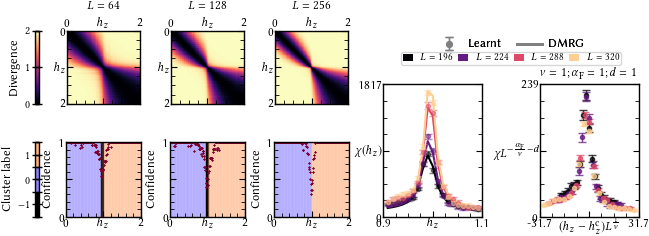

In [9]:
fig_width_cm = 16.5
fig_height_cm = 6
cm2inches = 1 / 2.54
def figsize_cm2inches(fig_width_cm, fig_height_cm):
    return (fig_width_cm * cm2inches, fig_height_cm * cm2inches)

# Specifying the figure layout
fig = plt.figure(figsize=figsize_cm2inches(fig_width_cm, fig_height_cm),
                constrained_layout=True)
grid_spec = fig.add_gridspec(nrows=4, 
                             ncols=6,                           
                             width_ratios=[0.05, 1, 1, 1, 1.25, 1.25])
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.03)

small_axes = {}
for row_idx in range(2):
    for col_idx in range(6):
        if col_idx in (4, 5, 6):
            continue
        small_axes[(row_idx, col_idx)] = fig.add_subplot(grid_spec[2 * row_idx:2 * row_idx + 2, col_idx])
susc_ax = fig.add_subplot(grid_spec[1:, 4:5])
fssa_ax = fig.add_subplot(grid_spec[1:, 5:6])

legend_ax = fig.add_subplot(grid_spec[0, 4:6])
legend_ax.axis('off')

# Adding distance matrices
for exp_config_idx, exp_config in enumerate(f_matrices_dict.keys()):
    system_size = exp_config.system_size
    transverse_fields = np.asarray(coords_dict[exp_config])[:, 0]
    cur_ax = small_axes[0, exp_config_idx + 1]
    im = cur_ax.matshow(f_matrices_dict[exp_config]['hellinger'],
                   cmap='magma',
                   vmin=0.0,
                   vmax=2.0)
    cur_ax.set_title(f'$L={system_size}$', fontsize=label_size)

    class_indices = [label_idx for label_idx, _ in enumerate(transverse_fields) if ((label_idx % 100) == 0)]
    class_names = [f'{transverse_fields[class_idx]:.0f}' for class_idx in class_indices]
    cur_ax.set_xticks(class_indices, class_names, fontsize=tick_size)
    cur_ax.set_yticks(class_indices, class_names, fontsize=tick_size)
    
    cur_ax.set_xlabel(r'$h_z$', fontsize=label_size)
    cur_ax.set_ylabel(r'$h_z$', fontsize=label_size)

cbar_ax = small_axes[0, 0]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')

# Put the entire y-axis (ticks + label) on the left of the bar
cbar.ax.yaxis.set_ticks_position('left')        # move tick marks & numbers
cbar.ax.yaxis.set_label_position('left')    
cbar.set_label('Divergence', fontsize=label_size, rotation=90)
cbar.ax.tick_params(labelsize=tick_size)

# Add clustering-confidence panels
for exp_config_idx, exp_config in enumerate(f_matrices_dict.keys()):
    system_size_idx = exp_config_idx
    system_size = exp_config.system_size
    cur_ax = small_axes[1, system_size_idx + 1]
    cluster_labels = cluster_labels_dict[exp_config]['hellinger']

    cur_ax.plot(transverse_fields, 
                cluster_confidences_dict[exp_config]['hellinger'], 
                c='xkcd:bordeaux',
                linestyle='',
                marker='x', 
                ms=1)

    class_indices = [label_idx for label_idx, _ in enumerate(transverse_fields) if ((label_idx % 100) == 0)]
    class_names = [f'{transverse_fields[class_idx]:.0f}' for class_idx in class_indices]

    
    cur_ax.set_xlabel(r'$h_z$', fontsize=label_size)
    cur_ax.set_ylabel(r'Confidence', fontsize=label_size)

    cur_ax.set_xlim((min(transverse_fields), max(transverse_fields)))
    cur_ax.set_ylim((0, 1))
    for transverse_field_idx in range(len(transverse_fields)):
        x_axis = transverse_fields
        if transverse_field_idx == 0:
            left_border = x_axis[0]
            right_border = 0.5 * (x_axis[1] + x_axis[0])
        elif transverse_field_idx == len(x_axis) - 1:
            left_border = 0.5 * (x_axis[-1] + x_axis[-2])
            right_border = x_axis[-1]
        else:
            left_border = 0.5 * (x_axis[transverse_field_idx] + x_axis[transverse_field_idx - 1])
            right_border = 0.5 * (x_axis[transverse_field_idx] + x_axis[transverse_field_idx + 1])
        cur_ax.axvspan(left_border, 
                       right_border, 
                       color=class_to_colour.get(cluster_labels[transverse_field_idx], 'xkcd:black'), 
                       alpha=0.15 if (cluster_labels[transverse_field_idx] + 1 != 0) else 1)

cbar_ax = small_axes[1, 0]                         # keep the same slot
cluster_cbar = fig.colorbar(cluster_mappable,
                            cax=cbar_ax,
                            orientation='vertical',
                            ticks=all_labels,      # [-1, 0, 1]
                            boundaries=cluster_bounds,
                            spacing='proportional')

cluster_cbar.ax.yaxis.set_ticks_position('left')
cluster_cbar.ax.yaxis.set_label_position('left')
cluster_cbar.set_label('Cluster label', fontsize=label_size, rotation=90)
cluster_cbar.ax.tick_params(labelsize=tick_size, size=0)

# Plot susceptibility curves and FSS collapse
susc_cmap = cm.get_cmap('magma')
n_configs = len(fssa_system_sizes)
colors = susc_cmap(np.linspace(0.0, 0.9, n_configs))
for system_size_idx, system_size in enumerate(fssa_system_sizes):
    susc_ax.errorbar(fssa_control_parameters,
                     fssa_susceptibility[system_size_idx],
                     yerr=fssa_susceptibility_std[system_size_idx],
                     marker='o',
                     color=colors[system_size_idx],
                     linestyle='',
                     markersize=3,
                     alpha=0.5,
                     capsize=3,
                     elinewidth=1,
                     capthick=1,
                     label=f'$L={system_size}$')
    delta = fssa_control_parameters[1] - fssa_control_parameters[0]

    if system_size in system_size2overlaps:
        theor_dist_matrix = 2 * (1 - np.abs(system_size2overlaps[system_size]))
        theor_dist_matrix = np.nan_to_num(theor_dist_matrix, nan=0.0)
        theor_diag = np.diag(theor_dist_matrix, k=1)
        theor_diag = 0.5 * (theor_diag[1:] + theor_diag[:-1])
        susc_ax.plot(fssa_control_parameters,
                    theor_diag / (delta ** 2), 
                    label=f'L={system_size}',
                    color=colors[system_size_idx],) 
         
    transverse_fields = fssa_control_parameters
    diag = fssa_susceptibility[system_size_idx]
    diag_std = fssa_susceptibility_std[system_size_idx]
    critical_h_z = 1.0
    nu = 1.
    alpha = 1.0
    d = 1
    L = system_size * 1.
    fssa_ax.set_title(f'$\\nu = {nu:.0f}; \\alpha_{{\\mathrm F}} = {alpha:.0f}; d = {d}$', fontsize=label_size)
    fssa_ax.errorbar(((transverse_fields - critical_h_z) * L**(1/nu)),
                ((diag / delta**2) * L**(-alpha/nu - d)),
                yerr=((diag_std / delta**2) * L**(-alpha/nu - d)),
                marker='o',
                linestyle='',
                markersize=3,
                alpha=0.75,
                capsize=3,
                elinewidth=1,
                capthick=1,
                label=f'L = {exp_config.system_size}, $\Delta h_z = ${delta:.3f}',
                color=colors[system_size_idx])



for (row_idx, col_idx), ax in small_axes.items():
    if (1 <= col_idx <= 3):
        if row_idx == 0:    
            compact_axes(ax, 
                        x_tex=r'$h_z$',
                        xmin_label=0,
                        xmax_label=2,
                        y_tex=r'$h_z$',
                        ymin_label=2,
                        ymax_label=0,)
        else:
            compact_axes(ax, 
                     x_tex=r'$h_z$',
                     xmin_label=0,
                     xmax_label=2,
                     y_tex=r'',
                     ymin_label=0,
                     ymax_label=1,)
            ax.set_ylabel('Confidence', fontsize=label_size)
            ax.set_aspect(ax.get_xlim()[1] / ax.get_ylim()[1])
    else:
        ax.tick_params(axis='both',         # x and y
                    which='both',        # major and minor
                    direction='in',
                    labelsize=tick_size, 
                    width=axes_linewidth,
                    size=5,
                    top=True,
                    right=True)

compact_axes(susc_ax,
            x_tex=r'$h_z$',
            xmin_label=0.9,
            xmax_label=1.1,
            y_tex=r'$\chi(h_z)$',
            ymin_label=0,
            #ymax_label=f'{1 * np.max(measurements):.0f}',
            )

compact_axes(fssa_ax,
            x_tex=r'$(h_z - h_z^{\rm c}) L ^{\frac{1}{\nu}}$', 
            # xmin_label=-20,
            # xmax_label=20,
            y_tex=r'$\chi L^{-\frac{\alpha_{\mathrm F}}{\nu} - d}$',
            ymin_label=0,
            #ymax_label=f'{1 * np.max(measurements):.0f}',
            )


# --- legend: color patches for L, title explains styles ---
patch_handles = [
    Patch(
        facecolor=colors[system_size_idx],
        edgecolor='none',
        label=fr'$L={system_size}$',
    )
    for system_size_idx, system_size in enumerate(fssa_system_sizes)
]
# --- Legend A: color patches for L ---
leg_L = legend_ax.legend(
    handles=patch_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.15),
    ncol=4,
    columnspacing=0.6,
    fontsize=label_size - 2,
    handlelength=1.0,
    handleheight=0.8,
    borderpad=0.2,
    labelspacing=0.3,
)
legend_ax.add_artist(leg_L)  # keep it when adding a second legend

# --- Legend B: style key (grey proxies) ---
# proxy "learnt" errorbar (dummy point)
# --- Legend B: style key (grey proxies) ---

# --- style legend (proxy artists) ---
err = legend_ax.errorbar(
    [0], [0],
    yerr=[1],
    fmt='o',
    color='0.5',
    linestyle='',
    markersize=4,
    capsize=3,
    elinewidth=1,
    capthick=1,
)

dmrg_proxy = Line2D(
    [0], [0],
    linestyle='-',
    linewidth=2.0,
    color='0.5',
)

style_leg = legend_ax.legend(
    handles=[err, dmrg_proxy],
    labels=['Learnt', 'DMRG'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    fontsize=label_size,
    handletextpad=0.6,
    columnspacing=1.2,
)

legend_ax.add_artist(style_leg)

# --- IMPORTANT: remove the proxy artists so nothing gets plotted ---
data_line, cap_lines, bar_cols = err.lines
data_line.remove()
for cap in cap_lines:
    cap.remove()
for barcol in bar_cols:
    barcol.remove()


fig.savefig('./figure_3.pdf',
            bbox_inches="tight",   # ← main switch
            pad_inches=0.00)
fig.savefig('./figure_3.svg',
            bbox_inches="tight",   # ← main switch
            pad_inches=0.00)